# Breast Cancer Classification using Support Vector Machine (SVM)

## Objective
The objective of this project is to classify breast cancer tumors as malignant or benign using Support Vector Machine (SVM) models. Different kernels and hyperparameters were explored to analyze their effect on model performance.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
cancer=load_breast_cancer()

In [4]:
print(cancer.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [5]:
df=pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

In [6]:
df["target"]=cancer.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [7]:
print(df.shape)

(569, 31)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

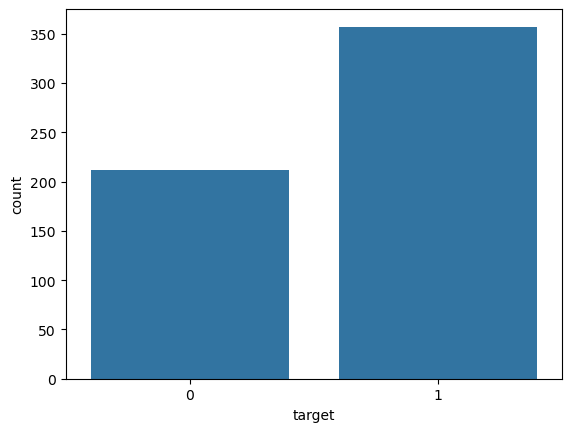

In [9]:
sns.countplot(x=df['target'])
plt.show()

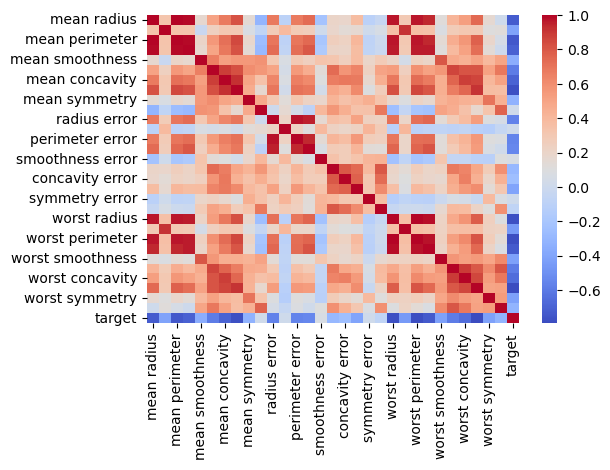

In [10]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

The correlation heatmap showed that several features were highly correlated, indicating redundancy among certain measurements such as radius, perimeter, and area.

In [11]:
X=df.drop('target',axis=1)
Y=df['target']

In [12]:
#splitting (train-test split)
X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [13]:
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [14]:
#scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [15]:
pd.DataFrame(X_train_scaled).head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,-1.440753,-0.435319,-1.362085,-1.139118,0.780573,0.718921,2.823135,-0.119150,1.092662,2.458173,...,-1.232861,-0.476309,-1.247920,-0.973968,0.722894,1.186732,4.672828,0.932012,2.097242,1.886450
1,1.974096,1.733026,2.091672,1.851973,1.319843,3.426275,2.013112,2.665032,2.127004,1.558396,...,2.173314,1.311279,2.081617,2.137405,0.761928,3.265601,1.928621,2.698947,1.891161,2.497838
2,-1.399982,-1.249622,-1.345209,-1.109785,-1.332645,-0.307355,-0.365558,-0.696502,1.930333,0.954379,...,-1.295284,-1.040811,-1.245220,-0.999715,-1.438693,-0.548564,-0.644911,-0.970239,0.597602,0.057894
3,-0.981797,1.416222,-0.982587,-0.866944,0.059390,-0.596788,-0.820203,-0.845115,0.313264,0.074041,...,-0.829197,1.593530,-0.873572,-0.742947,0.796624,-0.729392,-0.774950,-0.809483,0.798928,-0.134497
4,-1.117700,-1.010259,-1.125002,-0.965942,1.269511,-0.439002,-0.983341,-0.930600,3.394436,0.950213,...,-1.085129,-1.334616,-1.117138,-0.896549,-0.174876,-0.995079,-1.209146,-1.354582,1.033544,-0.205732


## Training Linear SVM

A linear kernel SVM model was trained to classify tumors using a linear decision boundary.

In [16]:
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_scaled, Y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [17]:
Y_pred=svm_model.predict(X_test_scaled)

In [18]:
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.956140350877193


In [19]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [20]:
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

[[41  2]
 [ 3 68]]


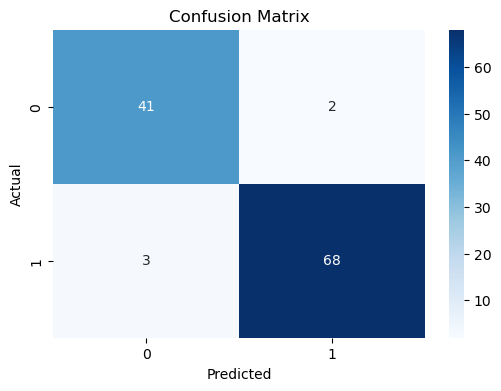

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix")
plt.show()

### Creating RBF Model

In [22]:
rbf_model = SVC(kernel='rbf')
rbf_model.fit(X_train_scaled, Y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [23]:
rbf_pred = rbf_model.predict(X_test_scaled)

In [24]:
rbf_accuracy = accuracy_score(Y_test, rbf_pred)
print("RBF Accuracy:", rbf_accuracy)

RBF Accuracy: 0.9824561403508771


In [25]:
print(classification_report(Y_test, rbf_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



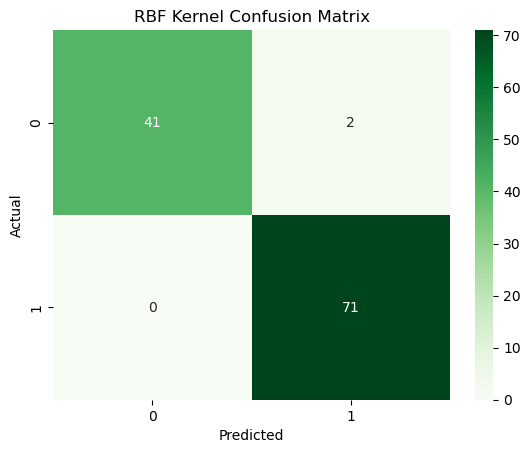

In [26]:
rbf_cm = confusion_matrix(Y_test, rbf_pred)
sns.heatmap(rbf_cm, annot=True, fmt='d', cmap='Greens')
plt.title("RBF Kernel Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Hyperparameter Tuning

Different values of:
- Gamma
- C parameter

were tested to study their impact on model performance and overfitting behavior.

In [27]:
gamma_values = [0.001, 0.01, 0.1, 1, 10, 100]
for gamma in gamma_values:
    model = SVC(
        kernel='rbf',
        gamma=gamma
    )
    model.fit(X_train_scaled, Y_train)
    predictions = model.predict(X_test_scaled)
    accuracy = accuracy_score(Y_test, predictions)

    print(f"Gamma: {gamma}")
    print(f"Accuracy: {accuracy}")
    print("-------------------")

Gamma: 0.001
Accuracy: 0.9649122807017544
-------------------
Gamma: 0.01
Accuracy: 0.9649122807017544
-------------------
Gamma: 0.1
Accuracy: 0.9649122807017544
-------------------
Gamma: 1
Accuracy: 0.631578947368421
-------------------
Gamma: 10
Accuracy: 0.6228070175438597
-------------------
Gamma: 100
Accuracy: 0.6228070175438597
-------------------


In [28]:
c_values = [0.01, 0.1, 1, 10, 100]
for c in c_values:
    model = SVC(
        kernel='rbf',
        C=c
    )
    model.fit(X_train_scaled, Y_train)
    predictions = model.predict(X_test_scaled)
    accuracy = accuracy_score(Y_test, predictions)

    print(f"C: {c}")
    print(f"Accuracy: {accuracy}")
    print("-------------------")    

C: 0.01
Accuracy: 0.6228070175438597
-------------------
C: 0.1
Accuracy: 0.9473684210526315
-------------------
C: 1
Accuracy: 0.9824561403508771
-------------------
C: 10
Accuracy: 0.9736842105263158
-------------------
C: 100
Accuracy: 0.9385964912280702
-------------------


### GridSearchCV Optimization

GridSearchCV was used to automatically search for the best combination of hyperparameters using cross-validation.

In [29]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

In [30]:
grid = GridSearchCV(
    SVC(),
    param_grid,
    refit=True,
    verbose=3,
    cv=5
)

In [31]:
grid.fit(X_train_scaled, Y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.747 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.703 total time=   0.0s
[CV 3/5] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.725 total time=   0.0s
[CV 4/5] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.681 total time=   0.0s
[CV 5/5] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.703 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.934 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.934 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.956 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.945 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.934 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.912 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [0.001, 0.01, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [32]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
0.9736263736263737


In [33]:
best_model = grid.best_estimator_
best_predictions = best_model.predict(X_test_scaled)
print((accuracy_score(Y_test,best_predictions)))

0.9824561403508771


### PCA visualisation

In [34]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

In [35]:
X_pca = pca.fit_transform(X_train_scaled)

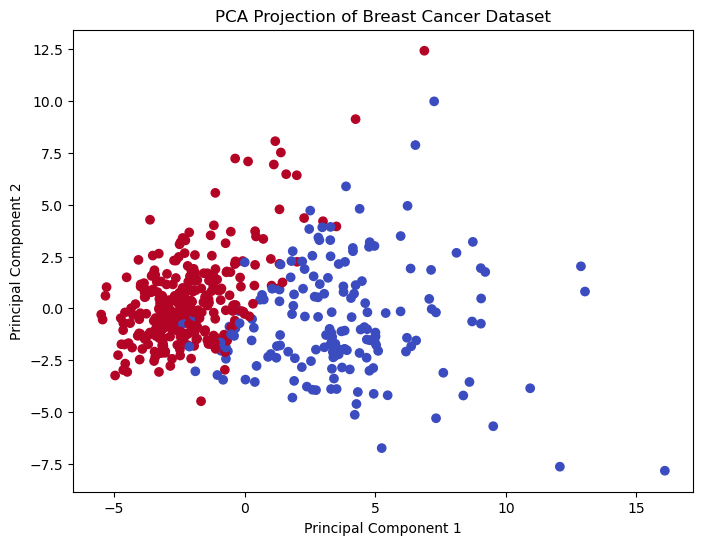

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=Y_train,
    cmap='coolwarm'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Projection of Breast Cancer Dataset")

plt.show()

### Linear SVM Decision Boundary

To understand how a linear kernel separates the data, a linear SVM was trained on the PCA-transformed dataset and its decision boundary was visualized.

In [37]:
linear_pca_svm = SVC(kernel='linear')
linear_pca_svm.fit(X_pca, Y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [39]:
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

In [40]:
Z_linear = linear_pca_svm.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z_linear = Z_linear.reshape(xx.shape)

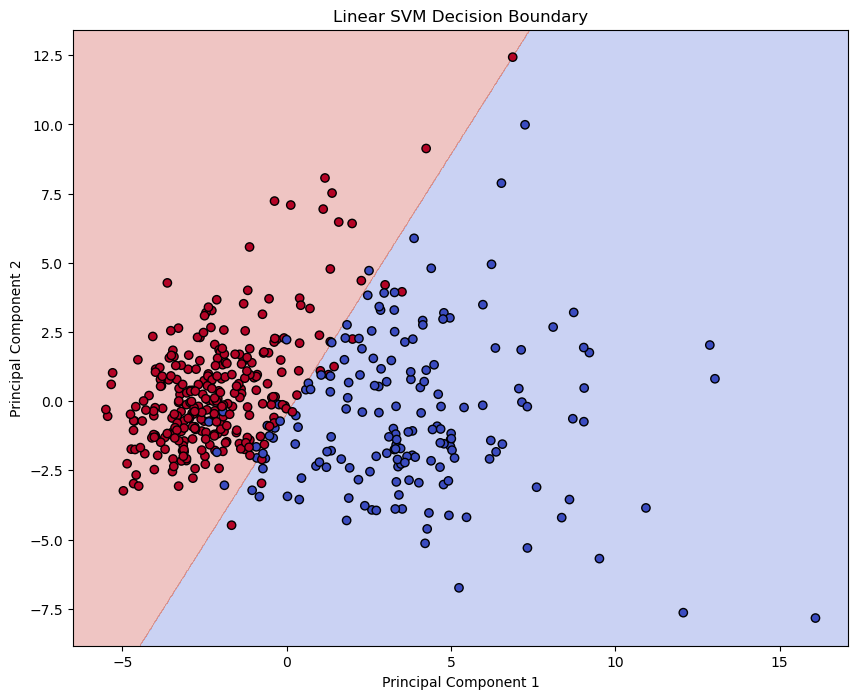

In [41]:
plt.figure(figsize=(10,8))

plt.contourf(
    xx,
    yy,
    Z_linear,
    alpha=0.3,
    cmap='coolwarm'
)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=Y_train,
    cmap='coolwarm',
    edgecolors='k'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Linear SVM Decision Boundary")

plt.show()

### SVM Decision Boundary Visualization

The decision boundary of the RBF kernel SVM was visualized using PCA-transformed data to understand class separation.

In [42]:
pca_svm = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)
pca_svm.fit(X_pca, Y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [43]:
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

In [44]:
Z = pca_svm.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

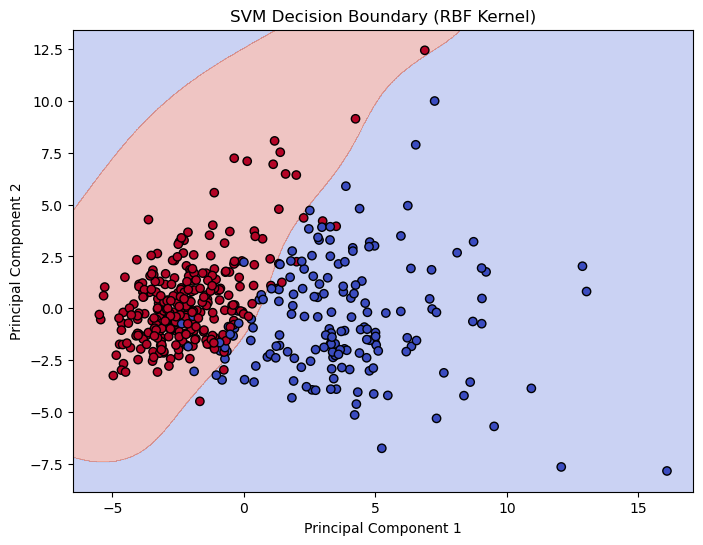

In [47]:
plt.figure(figsize=(8,6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap='coolwarm'
)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=Y_train,
    cmap='coolwarm',
    edgecolors='k'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("SVM Decision Boundary (RBF Kernel)")

plt.show()

### Support Vector Visualization

Support vectors are the critical data points closest to the decision boundary that define the SVM classifier.

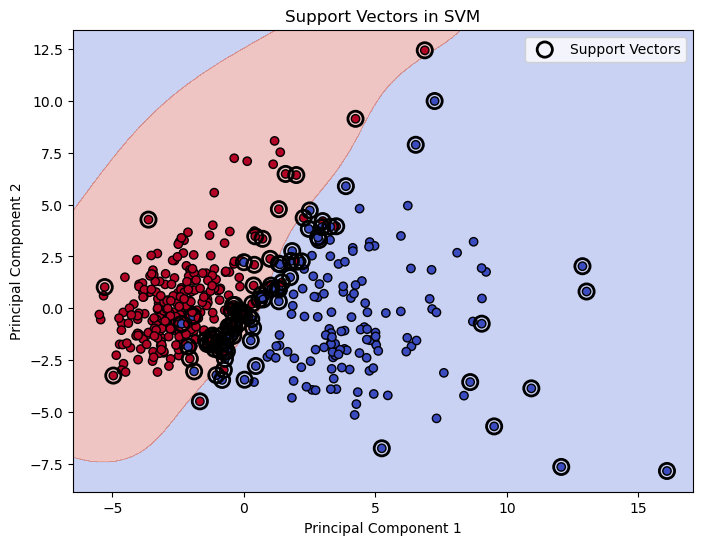

In [48]:
plt.figure(figsize=(8,6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap='coolwarm'
)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=Y_train,
    cmap='coolwarm',
    edgecolors='k'
)

# SUPPORT VECTORS
plt.scatter(
    pca_svm.support_vectors_[:, 0],
    pca_svm.support_vectors_[:, 1],
    s=120,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Support Vectors in SVM")

plt.legend()

plt.show()